캘리포니아 주택 데이터셋

In [1]:
# tensorflow 캘리포니아 주택
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
data = fetch_california_housing()

x_train_full,x_test,y_train_full,y_test = train_test_split(data.data, data.target, random_state=42) # 75: 25 testsize
x_train,x_val,y_train,y_val = train_test_split(x_train_full, y_train_full, random_state=42)
x_train.shape, x_val.shape, x_test.shape

((11610, 8), (3870, 8), (5160, 8))

- 훈련데이터 가중치를 학습
- 미니배치 경사하강법 + 역전파
- 손실을 줄이도록 파라메터를 반복 업데이트

In [2]:
x_train.shape[1:]

(8,)

In [3]:
import tensorflow as tf
tf.random.set_seed(42)

normal_layer = tf.keras.layers.Normalization(input_shape=(8,))


model = tf.keras.Sequential([
    normal_layer,
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(loss='mse', optimizer='adam', metrics=['RootMeanSquaredError'])
normal_layer.adapt(x_train)  
history = model.fit(x_train, y_train,epochs=50,validation_data=(x_val, y_val))

Epoch 1/50


c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.9177 - loss: 0.8422 - val_RootMeanSquaredError: 0.6668 - val_loss: 0.4446
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6176 - loss: 0.3815 - val_RootMeanSquaredError: 0.6000 - val_loss: 0.3601
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5894 - loss: 0.3474 - val_RootMeanSquaredError: 0.5716 - val_loss: 0.3267
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5792 - loss: 0.3354 - val_RootMeanSquaredError: 0.5924 - val_loss: 0.3509
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5700 - loss: 0.3249 - val_RootMeanSquaredError: 0.6959 - val_loss: 0.4842
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5690 - loss: 0.3237 - val_RootMeanSquaredError: 0.6258 - val_loss: 0.3916
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5586 - loss: 0.3121 -

In [4]:
# 성능 측정
model.evaluate(x_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - RootMeanSquaredError: 0.5307 - loss: 0.2817


[0.28168511390686035, 0.5307401418685913]

In [5]:
history.history.keys()

dict_keys(['RootMeanSquaredError', 'loss', 'val_RootMeanSquaredError', 'val_loss'])

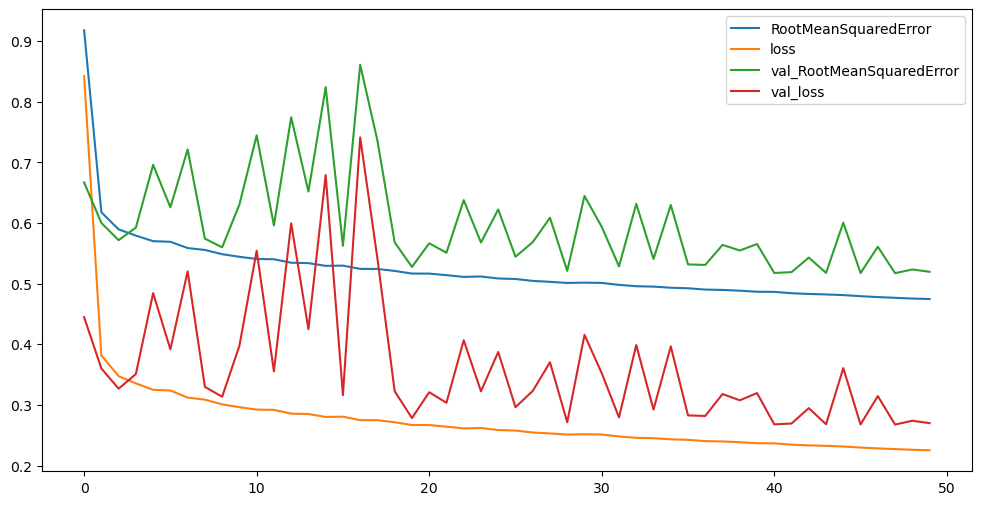

In [6]:
import matplotlib.pyplot as plt
plt.subplots(figsize=(12,6))
plt.plot(range(50),history.history['RootMeanSquaredError'], label = 'RootMeanSquaredError')
plt.plot(range(50),history.history['loss'], label = 'loss')
plt.plot(range(50),history.history['val_RootMeanSquaredError'], label = 'val_RootMeanSquaredError')
plt.plot(range(50),history.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

In [7]:
from sklearn.metrics import r2_score
y_predict = model.predict(x_test)
r2_score(y_test,y_predict)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step


0.787121199864364

In [8]:
from sklearn.ensemble import RandomForestRegressor
sk_model = RandomForestRegressor(random_state=42)
sk_model.fit(x_train,y_train)
sk_y_predict = sk_model.predict(x_test)
r2_score(y_test,sk_y_predict)
# 퓨처가 많이 있으면 딥러닝이 더 좋다. 

0.8001601142626265

함수형 API를 사용한 복잡한 모델 구축
 - 와이드 & 딥 신경망 : 입력의 전부 또는 일부를 출력레이어 직접연결
 - 선형관계와 비선형표현을 동시에 학습해 편향/분산 의 균형을 맞춤
 - 저차원과 고차원 정보를 합쳐서 정보손실을 줄임

In [9]:
import tensorflow as tf
tf.keras.backend.clear_session() # 세션에 이전 학습이 남아있으면 지워준다.
tf.random.set_seed(42)
input = tf.keras.layers.Input(shape=x_train.shape[1:])
normalization_layer = tf.keras.layers.Normalization()
hidden_layer1 = tf.keras.layers.Dense(50, activation='relu')
hidden_layer2 = tf.keras.layers.Dense(50, activation='relu')
output_layer = tf.keras.layers.Dense(1)
concat_layer = tf.keras.layers.Concatenate()

normalization = normalization_layer(input)
hidden1 = hidden_layer1(normalization)
hidden2 = hidden_layer2(hidden1)
concat = concat_layer([normalization, hidden2])
output = output_layer(concat)

model = tf.keras.Model(inputs=[input], outputs=[output])
model.summary() # 파라메터 개수 확인 ? 데이터 수에 비해 과도하면 과적합 위험이 있어서 확인

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 8)         │         17 │ input_layer[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50)        │        450 │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50)        │      2,550 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 58)        │          0 │ normalization[0]… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         59 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,076 (12.02 KB)

 Trainable params: 3,059 (11.95 KB)

 Non-trainable params: 17 (72.00 B)

In [10]:
model.compile(loss='mse', optimizer='adam', metrics=['RootMeanSquaredError'])
normalization_layer.adapt(x_train)
history = model.fit(x_train,y_train, epochs=50, validation_data=(x_val,y_val))

Epoch 1/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 1.0355 - loss: 1.0723 - val_RootMeanSquaredError: 0.9862 - val_loss: 0.9725
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6531 - loss: 0.4265 - val_RootMeanSquaredError: 1.5232 - val_loss: 2.3201
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6144 - loss: 0.3775 - val_RootMeanSquaredError: 1.4652 - val_loss: 2.1468
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6166 - loss: 0.3801 - val_RootMeanSquaredError: 1.8723 - val_loss: 3.5054
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6032 - loss: 0.3638 - val_RootMeanSquaredError: 1.9469 - val_loss: 3.7906
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6063 - loss: 0.3677 - val_RootMeanSquaredError: 2.4561 - val_loss: 6.0323
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6051 - los

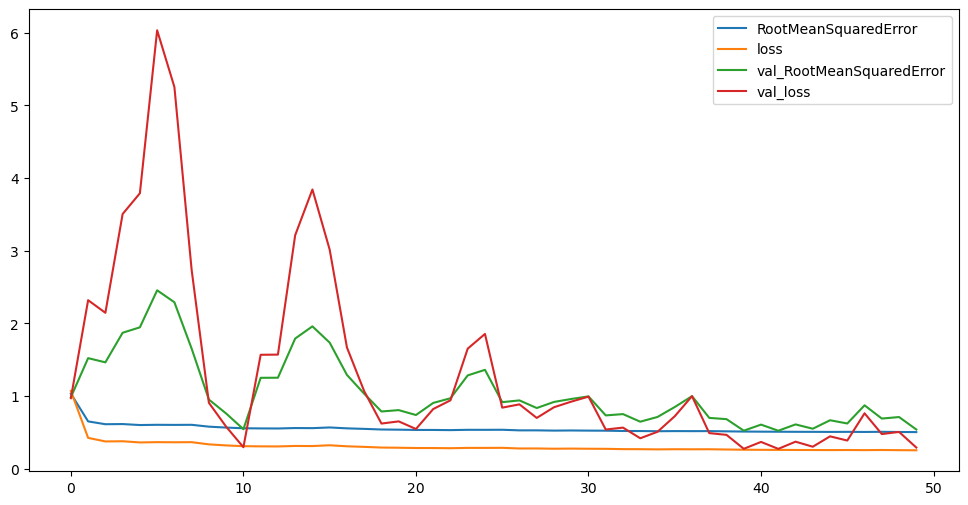

In [11]:
import matplotlib.pyplot as plt
plt.subplots(figsize=(12,6))
plt.plot(range(50),history.history['RootMeanSquaredError'], label = 'RootMeanSquaredError')
plt.plot(range(50),history.history['loss'], label = 'loss')
plt.plot(range(50),history.history['val_RootMeanSquaredError'], label = 'val_RootMeanSquaredError')
plt.plot(range(50),history.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

In [12]:
from sklearn.metrics import r2_score
y_predict = model.predict(x_test)
r2_score(y_test,y_predict)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step


0.7920960178133083

다중경로

In [ ]:
x_train_wide, x_train_deep = x_train[:, :5], x_train[:, 2:]
x_val_wide, x_val_deep = x_val[:, :5], x_val[:, 2:]
x_test_wide, x_test_deep = x_test[:, :5], x_test[:, 2:]

input_wide = tf.keras.layers.Input(shape=[5]) # 0 ~ 4 까지 특성
input_deep = tf.keras.layers.Input(shape=[6]) # 2 ~ 7 특성
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)

hidden1 = tf.keras.layers.Dense(30, activation='relu')(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation='relu')(hidden1)

concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)

aux_output = tf.keras.layers.Dense(1)(hidden2)

model = tf.keras.Model(inputs = [input_wide, input_deep], outputs = [output, aux_output])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss =('mse','mse'), loss_weights=(0.9,0.1), optimizer=optimizer, metrics=['RootMeanSquaredError', 'RootMeanSquaredError'])

norm_layer_wide.adapt(x_train_wide) # <- 중요
norm_layer_deep.adapt(x_train_deep) # <- 중요
history = model.fit(
    (x_train_wide, x_train_deep), (y_train, y_train), epochs=20,
    validation_data= ((x_val_wide, x_val_deep), (y_val, y_val))
)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - dense_33_RootMeanSquaredError: 1.1406 - dense_33_loss: 1.3007 - dense_34_RootMeanSquaredError: 1.4465 - dense_34_loss: 2.0917 - loss: 1.3802 - val_dense_33_RootMeanSquaredError: 0.7387 - val_dense_33_loss: 0.5455 - val_dense_34_RootMeanSquaredError: 2.0219 - val_dense_34_loss: 4.0861 - val_loss: 0.8998
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - dense_33_RootMeanSquaredError: 0.6975 - dense_33_loss: 0.4866 - dense_34_RootMeanSquaredError: 0.8798 - dense_34_loss: 0.7739 - loss: 0.5153 - val_dense_33_RootMeanSquaredError: 0.6610 - val_dense_33_loss: 0.4368 - val_dense_34_RootMeanSquaredError: 1.2141 - val_dense_34_loss: 1.4734 - val_loss: 0.5406
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - dense_33_RootMeanSquaredError: 0.6520 - dense_33_loss: 0.4251 - dense_34_RootMeanSquaredError: 0.7761 - dense_34_loss: 0.6023 - loss: 0.4428 - val_dense_33_RootMeanSquaredError: 0.6555 - val_dense_33_loss: 0.4296 - val_dense_34_Ro

In [21]:
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_17    │ (None, 6)         │         13 │ input_layer_16[0… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_15      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 30)        │        210 │ normalization_17… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_16    │ (None, 5)         │         11 │ input_layer_15[0… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 30)        │        930 │ dense_31[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 35)        │          0 │ normalization_16… │
│ (Concatenate)       │                   │            │ dense_32[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 1)         │         36 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 1)         │         31 │ dense_32[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,647 (14.26 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 24 (104.00 B)

 Optimizer params: 2,416 (9.44 KB)

In [22]:
model.evaluate((x_test_wide, x_test_deep), (y_test,y_test))

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - dense_33_RootMeanSquaredError: 0.5754 - dense_33_loss: 0.3306 - dense_34_RootMeanSquaredError: 0.6254 - dense_34_loss: 0.3912 - loss: 0.3371


[0.33708593249320984,
 0.33063074946403503,
 0.3911798596382141,
 0.575392484664917,
 0.6254379153251648]

In [24]:
model.predict((x_test_wide, x_test_deep))

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


[array([[0.6517107],
        [1.0681381],
        [3.4913223],
        ...,
        [1.6270618],
        [2.4223864],
        [4.0059614]], shape=(5160, 1), dtype=float32),
 array([[0.8495687],
        [0.9499519],
        [3.2693083],
        ...,
        [1.5493838],
        [1.9496084],
        [3.8082395]], shape=(5160, 1), dtype=float32)]

In [25]:
y_test

array([0.477  , 0.458  , 5.00001, ..., 1.177  , 2.631  , 4.815  ],
      shape=(5160,))